In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
#nltk.download('stopwords')
from tensorflow.keras.layers import Embedding,Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import LSTM,Bidirectional,GRU
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [2]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
train.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [3]:
train.tail()

,id,title,author,text,label
20795,20795,Rapper T.I.: Trump a ’Poster Child For White S...,Jerome Hudson,Rapper T. I. unloaded on black celebrities who...,0
20796,20796,"N.F.L. Playoffs: Schedule, Matchups and Odds -...",Benjamin Hoffman,When the Green Bay Packers lost to the Washing...,0
20797,20797,Macy’s Is Said to Receive Takeover Approach by...,Michael J. de la Merced and Rachel Abrams,The Macy’s of today grew from the union of sev...,0
20798,20798,"NATO, Russia To Hold Parallel Exercises In Bal...",Alex Ansary,"NATO, Russia To Hold Parallel Exercises In Bal...",1
20799,20799,What Keeps the F-35 Alive,David Swanson,"David Swanson is an author, activist, journa...",1


In [4]:
test.head()

,id,title,author,text
0,20800,"Specter of Trump Loosens Tongues, if Not Purse...",David Streitfeld,"PALO ALTO, Calif. — After years of scorning..."
1,20801,Russian warships ready to strike terrorists ne...,NaN,Russian warships ready to strike terrorists ne...
2,20802,#NoDAPL: Native American Leaders Vow to Stay A...,Common Dreams,Videos #NoDAPL: Native American Leaders Vow to...
3,20803,"Tim Tebow Will Attempt Another Comeback, This ...",Daniel Victor,"If at first you don’t succeed, try a different..."
4,20804,Keiser Report: Meme Wars (E995),Truth Broadcast Network,42 mins ago 1 Views 0 Comments 0 Likes 'For th...


In [5]:
test.tail()

,id,title,author,text
5195,25995,The Bangladeshi Traffic Jam That Never Ends - ...,Jody Rosen,Of all the dysfunctions that plague the world’...
5196,25996,John Kasich Signs One Abortion Bill in Ohio bu...,Sheryl Gay Stolberg,WASHINGTON — Gov. John Kasich of Ohio on Tu...
5197,25997,"California Today: What, Exactly, Is in Your Su...",Mike McPhate,Good morning. (Want to get California Today by...
5198,25998,300 US Marines To Be Deployed To Russian Borde...,NaN,« Previous - Next » 300 US Marines To Be Deplo...
5199,25999,"Awkward Sex, Onscreen and Off - The New York T...",Teddy Wayne,Perhaps you’ve seen the new TV series whose pi...


In [6]:
print("There are {} number of rows and {} number of columns for training.".format(train.shape[0],train.shape[1]))
print("There are {} number of rows and {} number of columns for testing.".format(test.shape[0],test.shape[1]))

There are 20800 number of rows and 5 number of columns for training.
There are 5200 number of rows and 4 number of columns for testing.


In [7]:
# Checking the null values in training data.
train.isnull().sum()

id           0
title      558
author    1957
text        39
label        0
dtype: int64

In [8]:
# Checking the null values in testing data.
test.isnull().sum()

id          0
title     122
author    503
text        7
dtype: int64

In [9]:
# Handling nan values in dataset using empty spaces
train=train.fillna(" ")
test=test.fillna(" ")

In [10]:
# Creating a variable "merged" by merging columns "title" and "author"
train["merged"] = train["title"]+" "+train["author"]#+" "+train["text"]
test["merged"]  = test["title"]+" "+test["author"]#+" "+test["text"]

In [11]:
# Seperating Independent and dependent features
X = train.drop(columns=['label'],axis=1)
y = train['label']
X.head()

,id,title,author,text,merged
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,House Dem Aide: We Didn’t Even See Comey’s Let...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,"FLYNN: Hillary Clinton, Big Woman on Campus - ..."
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",Why the Truth Might Get You Fired Consortiumne...
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,15 Civilians Killed In Single US Airstrike Hav...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,Iranian woman jailed for fictional unpublished...


In [12]:
# Creating One-Hot Representations
df = X.copy()
df.reset_index(inplace=True)
df_test = test.copy()
df_test.reset_index(inplace=True)

In [13]:
# Performing data preprocessing on column 'title'
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
def stemming(data):
    '''Input: Data to be processed
       Output: Preprocessed data
    '''
    corpus = []
    stopwords_set=set(stopwords.words('english'))
    for i in range(0,len(data)):
        review = re.sub('[^a-zA-Z]',' ',data['merged'][i])
        review = review.lower()
        review = review.split()
        review = [ps.stem(word) for word in review if word not in stopwords_set]
        review = ' '.join(review)
        corpus.append(review)
    return corpus
    
train_corpus = stemming(df)
test_corpus  = stemming(df_test)
train_corpus[1]

'flynn hillari clinton big woman campu breitbart daniel j flynn'

In [14]:
test_corpus[1]

'russian warship readi strike terrorist near aleppo'

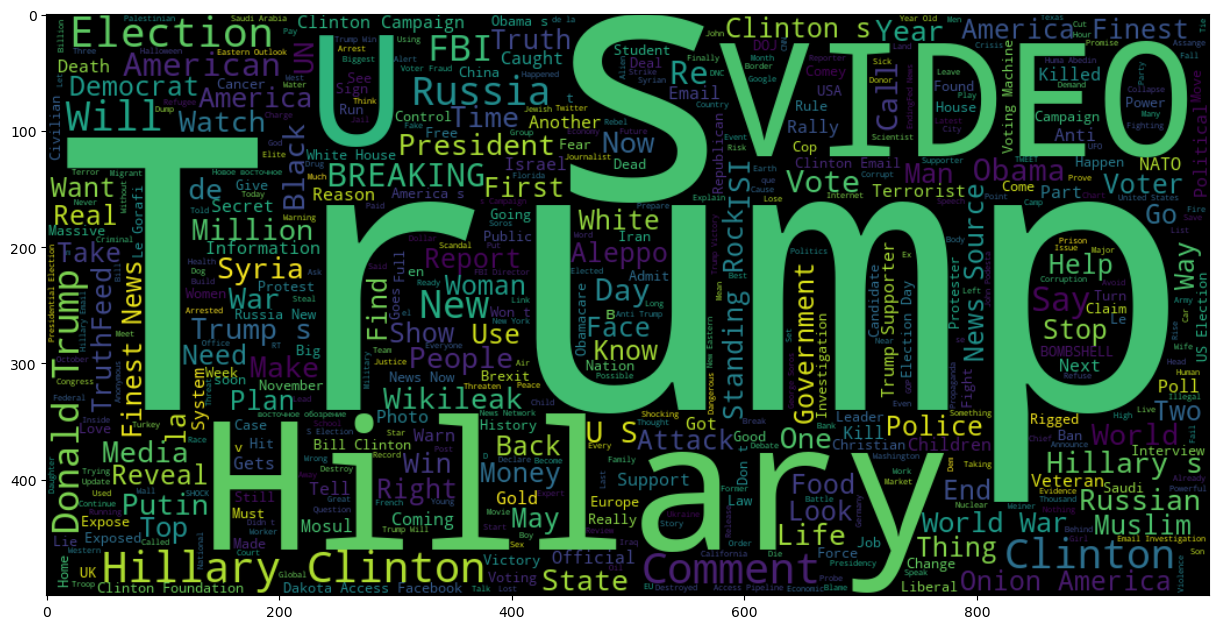

In [15]:
#WordCloud for Fake News
from wordcloud import WordCloud,STOPWORDS
plt.figure(figsize = (15,15))
wc = WordCloud(max_words = 500 , width = 1000 , height = 500 , stopwords = STOPWORDS).generate(" ".join(train[train.label == 1].title))
plt.imshow(wc , interpolation = 'bilinear')

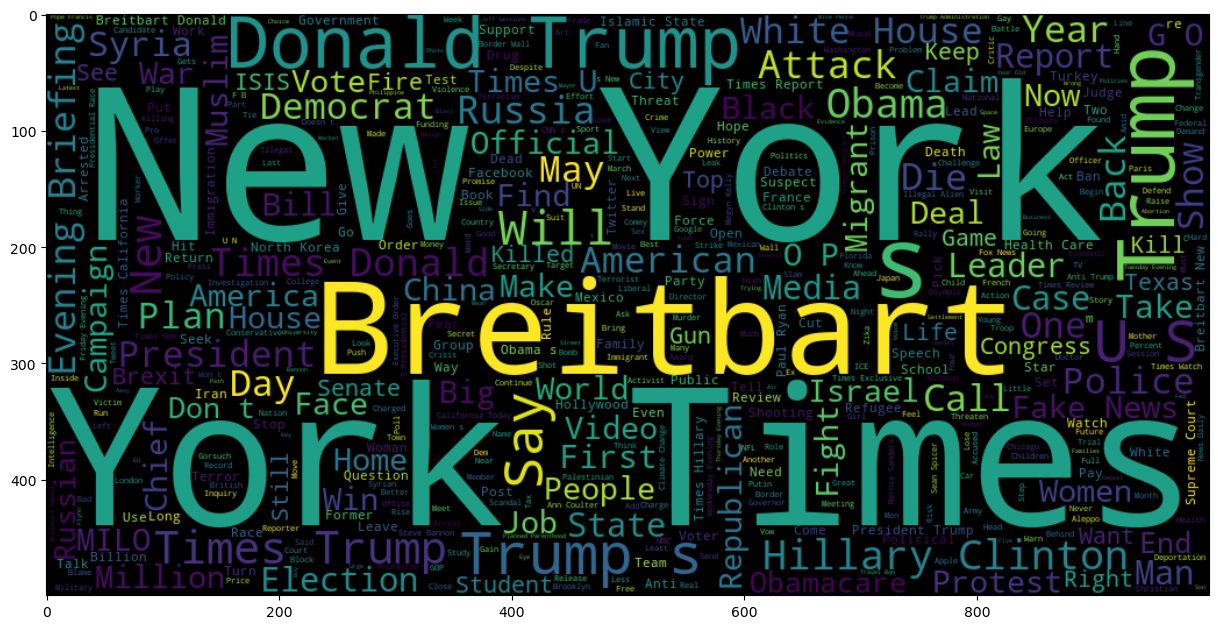

In [16]:
plt.figure(figsize = (15,15))
wc = WordCloud(max_words = 500 , width = 1000 , height = 500 , stopwords = STOPWORDS).generate(" ".join(train[train.label == 0].title))
plt.imshow(wc , interpolation = 'bilinear')

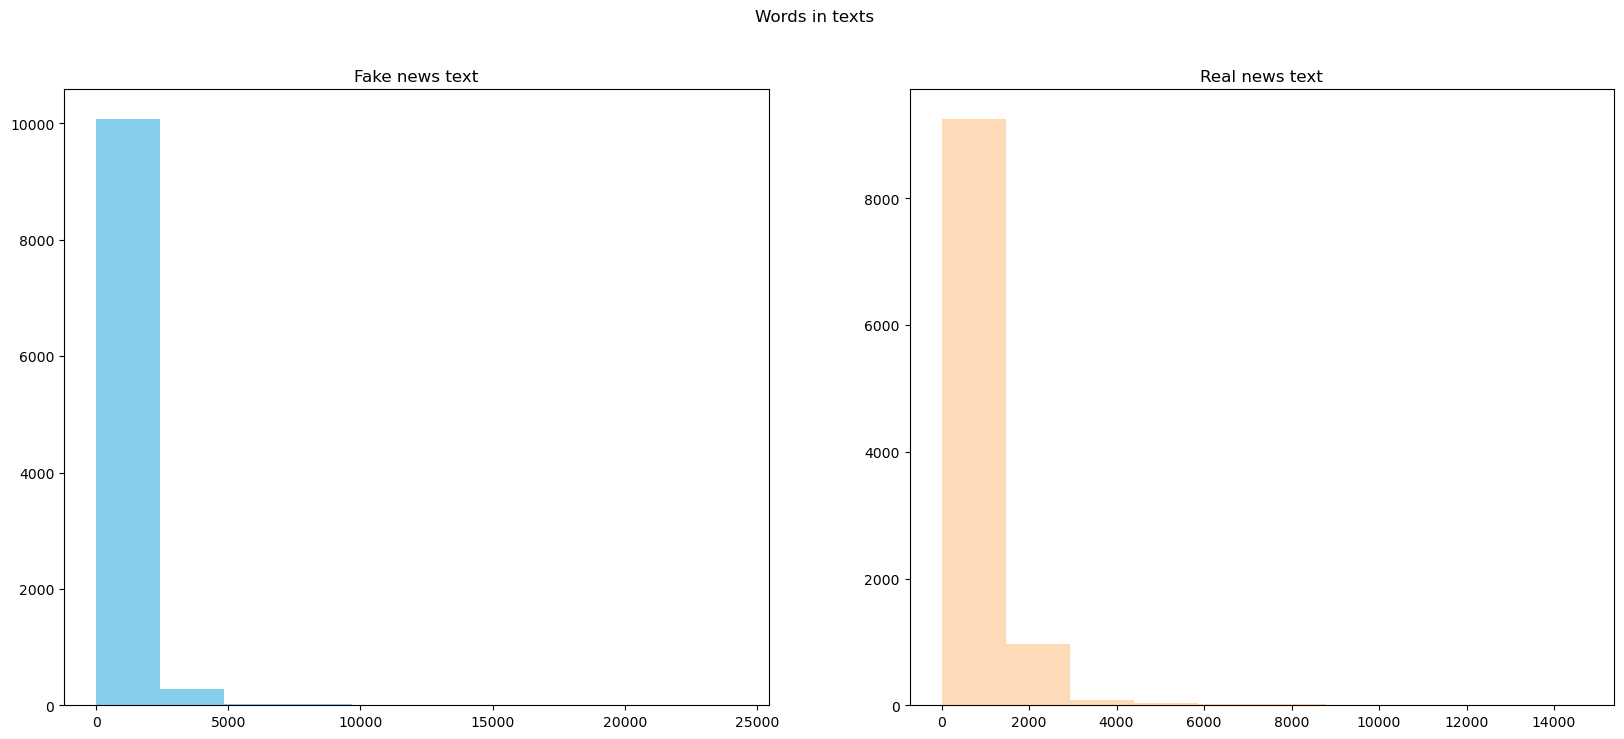

In [17]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(20,8))
text_len=train[train['label']==1]['text'].str.split().map(lambda x: len(x))
ax1.hist(text_len,color='SkyBlue')
ax1.set_title('Fake news text')
text_len=train[train['label']==0]['text'].str.split().map(lambda x: len(x))
ax2.hist(text_len,color='PeachPuff')
ax2.set_title('Real news text')
fig.suptitle('Words in texts')
plt.show()

In [18]:
# Converting to one-hot repr.
vocab_size = 5000
one_hot_train = [one_hot(word,vocab_size) for word in train_corpus]
one_hot_test  = [one_hot(word,vocab_size) for word in test_corpus]

In [19]:
one_hot_test[1]

[4370, 4403, 376, 2308, 3396, 1066, 1510]

In [20]:
# Embedding Representation 
sent_length = 20
embedd_docs_train = pad_sequences(one_hot_train,padding='pre',maxlen=sent_length)
embedd_docs_test  = pad_sequences(one_hot_test,padding='pre',maxlen=sent_length)
print(embedd_docs_train)

[[   0    0    0 ... 2712 2291 4463]
 [   0    0    0 ... 1965  987 1504]
 [   0    0    0 ... 2497  630  830]
 ...
 [   0    0    0 ... 1046 4970 2509]
 [   0    0    0 ... 1702  760 3729]
 [   0    0    0 ... 2916 1626 1990]]


In [21]:
print(embedd_docs_test)

[[   0    0    0 ... 3954 1626 4461]
 [   0    0    0 ... 3396 1066 1510]
 [   0    0    0 ... 3255 3303 2577]
 ...
 [   0    0    0 ... 3954  384 1679]
 [   0    0    0 ... 4370 4487 4704]
 [   0    0    0 ... 3954 1261 4112]]


In [22]:
# Converting Embedding repr. to array
x_final = np.array(embedd_docs_train)
y_final = np.array(y)
x_test_final = np.array(embedd_docs_test)

In [23]:
# Dimensions of prev. array repr.
x_final.shape,y_final.shape,x_test_final.shape

((20800, 20), (20800,), (5200, 20))

In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_final, y_final, test_size=0.1, random_state=42, stratify = y_final)
X_train, x_valid, Y_train, y_valid = train_test_split(x_train, y_train, test_size=0.1, random_state=42, stratify = y_train)
x_test_final = x_test_final

In [25]:
model_1 = LogisticRegression(max_iter=900)
model_1.fit(X_train,Y_train)
pred_1 = model_1.predict(x_test)
cr1    = classification_report(y_test,pred_1)
print(cr1)

              precision    recall  f1-score   support

           0       0.69      0.72      0.70      1039
           1       0.71      0.67      0.69      1041

    accuracy                           0.70      2080
   macro avg       0.70      0.70      0.70      2080
weighted avg       0.70      0.70      0.70      2080



In [26]:
model_2 = MultinomialNB()
model_2.fit(X_train,Y_train)
pred_2 = model_2.predict(x_test)
cr2    = classification_report(y_test,pred_2)
print(cr2)

              precision    recall  f1-score   support

           0       0.71      0.62      0.66      1039
           1       0.66      0.74      0.70      1041

    accuracy                           0.68      2080
   macro avg       0.68      0.68      0.68      2080
weighted avg       0.68      0.68      0.68      2080



In [27]:
model_3 = DecisionTreeClassifier()
model_3.fit(X_train,Y_train)
pred_3 = model_3.predict(x_test)
cr3    = classification_report(y_test,pred_3)
print(cr3)

              precision    recall  f1-score   support

           0       0.89      0.90      0.89      1039
           1       0.90      0.89      0.89      1041

    accuracy                           0.89      2080
   macro avg       0.89      0.89      0.89      2080
weighted avg       0.89      0.89      0.89      2080



In [28]:
model_4 = RandomForestClassifier()
model_4.fit(X_train,Y_train)
pred_4 = model_4.predict(x_test)
cr4    = classification_report(y_test,pred_4)
print(cr4)

              precision    recall  f1-score   support

           0       0.95      0.87      0.91      1039
           1       0.88      0.96      0.92      1041

    accuracy                           0.91      2080
   macro avg       0.91      0.91      0.91      2080
weighted avg       0.91      0.91      0.91      2080



In [29]:
model_5 = XGBClassifier()
model_5.fit(X_train,Y_train)
pred_5 = model_5.predict(x_test)
cr5    = classification_report(y_test,pred_5)
print(cr5)

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1039
           1       0.97      0.98      0.98      1041

    accuracy                           0.97      2080
   macro avg       0.98      0.97      0.97      2080
weighted avg       0.98      0.97      0.97      2080



In [40]:
model_6 = CatBoostClassifier(iterations=200)
model_6.fit(X_train,Y_train)
pred_6 = model_6.predict(x_test)
cr6    = classification_report(y_test,pred_6)
print(cr6)

Learning rate set to 0.150531
0:	learn: 0.5895103	total: 7.09ms	remaining: 1.41s
1:	learn: 0.5275509	total: 15.7ms	remaining: 1.55s
2:	learn: 0.4585361	total: 23.7ms	remaining: 1.55s
3:	learn: 0.4324926	total: 29.9ms	remaining: 1.46s
4:	learn: 0.3996675	total: 36.5ms	remaining: 1.42s
5:	learn: 0.3843517	total: 42.3ms	remaining: 1.37s
6:	learn: 0.3652197	total: 48.5ms	remaining: 1.34s
7:	learn: 0.3563900	total: 54.4ms	remaining: 1.3s
8:	learn: 0.3471373	total: 60.3ms	remaining: 1.28s
9:	learn: 0.3355860	total: 65.8ms	remaining: 1.25s
10:	learn: 0.3285121	total: 71.1ms	remaining: 1.22s
11:	learn: 0.3167847	total: 75.9ms	remaining: 1.19s
12:	learn: 0.3088965	total: 80.9ms	remaining: 1.16s
13:	learn: 0.3051261	total: 85.5ms	remaining: 1.14s
14:	learn: 0.2991735	total: 90.2ms	remaining: 1.11s
15:	learn: 0.2954622	total: 95ms	remaining: 1.09s
16:	learn: 0.2903847	total: 100ms	remaining: 1.08s
17:	learn: 0.2834358	total: 105ms	remaining: 1.06s
18:	learn: 0.2780991	total: 110ms	remaining: 1.05

In [31]:
# Creating the LSTM Model for prediction
embedding_feature_vector = 40
model = Sequential()
model.add(Embedding(vocab_size,embedding_feature_vector))
model.add(Dropout(0.2))
model.add(LSTM(128))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate = 0.001),metrics=['accuracy'])
model.build(input_shape=(None, sent_length)) 
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 40)         │       200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,657 (1.09 MB)

 Trainable params: 286,657 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

None


In [32]:
# Training the model
model.fit(X_train,Y_train,validation_data=(x_valid,y_valid),epochs=10,batch_size=64)

Epoch 1/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8264 - loss: 0.3535 - val_accuracy: 0.9888 - val_loss: 0.0376
Epoch 2/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9923 - loss: 0.0265 - val_accuracy: 0.9931 - val_loss: 0.0268
Epoch 3/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9978 - loss: 0.0110 - val_accuracy: 0.9920 - val_loss: 0.0308
Epoch 4/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9991 - loss: 0.0051 - val_accuracy: 0.9888 - val_loss: 0.0500
Epoch 5/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9996 - loss: 0.0023 - val_accuracy: 0.9877 - val_loss: 0.0337
Epoch 6/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9989 - loss: 0.0044 - val_accuracy: 0.9920 - val_loss: 0.0433
Epoch 7/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9999 - loss: 7.4848e-04 - val_accuracy: 0.9925 - val_loss: 0.0473
Epoch 8/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 1.8189e-04 - val_accu

In [33]:
predictions = model.predict(x_test)
rounded_predictions = np.round(predictions).astype(int)
if y_test.ndim > 1:
    y_test = np.argmax(y_test, axis=1)
cr = classification_report(y_test, rounded_predictions)
print(cr)



65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1039
           1       0.99      0.99      0.99      1041

    accuracy                           0.99      2080
   macro avg       0.99      0.99      0.99      2080
weighted avg       0.99      0.99      0.99      2080



In [41]:
score_1 = accuracy_score(y_test,pred_1)
score_2 = accuracy_score(y_test,pred_2)
score_3 = accuracy_score(y_test,pred_3)
score_4 = accuracy_score(y_test,pred_4)
score_5 = accuracy_score(y_test,pred_5)
score_6 = accuracy_score(y_test,pred_6)
score_7 = accuracy_score(y_test,rounded_predictions)
results = pd.DataFrame([["Logistic Regression",score_1],["Naive Bayes",score_2],["Decision Tree",score_3],
                       ["Random Forest",score_4],["XGBOOST",score_5],["CatBoost",score_6],["LSTM",score_7]],columns=["Model","Accuracy"])
results

,Model,Accuracy
0,Logistic Regression,0.698077
1,Naive Bayes,0.680288
2,Decision Tree,0.894712
3,Random Forest,0.911538
4,XGBOOST,0.975000
5,CatBoost,0.974519
6,LSTM,0.989423
